In [295]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as mp
import matplotlib.dates as mdates

# Task 2: Data Aquisition & Initial Visualization

In [296]:
#Load data


duchesne = pd.read_csv("../data/09277500_1980_2020.csv")
duchesne = duchesne.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
duchesne["Datetime"] = pd.to_datetime(duchesne["Datetime"])


moon_reservoir = pd.read_csv("../data/09291000_1980_2020.csv")
moon_reservoir = moon_reservoir.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
moon_reservoir["Datetime"] = pd.to_datetime(moon_reservoir["Datetime"])

weber_headwater = pd.read_csv("../data/10128500_1980_2020.csv")
weber_headwater = weber_headwater.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
weber_headwater["Datetime"] = pd.to_datetime(weber_headwater["Datetime"])

provo = pd.read_csv("../data/10154200_1980_2020.csv")
provo = provo.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
provo["Datetime"] = pd.to_datetime(provo["Datetime"])


In [297]:
#process the data, I chose to perform 2014,2015,2016,2017,2018, and 2019 as my 6 years
#Note that I have gone back to convert my data into MGD here, as the later tasks were hard to analyze in cfs

duchesne = duchesne.loc[duchesne.index[duchesne["Datetime"].dt.year == 2014].min():duchesne.index[duchesne["Datetime"].dt.year == 2019].max()]
duchesne["USGS_flow"] = duchesne["USGS_flow"]*0.646

moon_reservoir = moon_reservoir.loc[moon_reservoir.index[moon_reservoir["Datetime"].dt.year == 2014].min():moon_reservoir.index[moon_reservoir["Datetime"].dt.year == 2019].max()]
moon_reservoir["USGS_flow"] = moon_reservoir["USGS_flow"]*0.646

weber_headwater = weber_headwater.loc[weber_headwater.index[weber_headwater["Datetime"].dt.year == 2014].min():weber_headwater.index[weber_headwater["Datetime"].dt.year == 2019].max()]
weber_headwater["USGS_flow"] = weber_headwater["USGS_flow"]*0.646

provo = provo.loc[provo.index[provo["Datetime"].dt.year == 2014].min():provo.index[provo["Datetime"].dt.year == 2019].max()]
provo["USGS_flow"] = provo["USGS_flow"]*0.646

streamflow = duchesne.merge(moon_reservoir.merge(weber_headwater.merge(provo,how="outer",on="Datetime",sort=True,suffixes = ['_weber','_provo']),how="outer",on="Datetime",sort=True),how="outer",on="Datetime",sort=True,suffixes=['_duch','_moon'])
streamflow.set_index("Datetime",inplace=True) #Note to self: this set_index requires to hit "run all" or the code block doesn't work

#Rename columns to be accurate with data
streamflow = streamflow.rename(columns={"USGS_flow_duch":"Duchesne Site","USGS_flow_moon":"Moon Lake Reservoir", "USGS_flow_provo":"Provo Site","USGS_flow_weber":"Weber Headwater Catchment"})

array([[<Axes: xlabel='Datetime', ylabel='Streamflow (MGD)'>,
        <Axes: xlabel='Datetime', ylabel='Streamflow (MGD)'>],
       [<Axes: xlabel='Datetime', ylabel='Streamflow (MGD)'>,
        <Axes: xlabel='Datetime', ylabel='Streamflow (MGD)'>]],
      dtype=object)

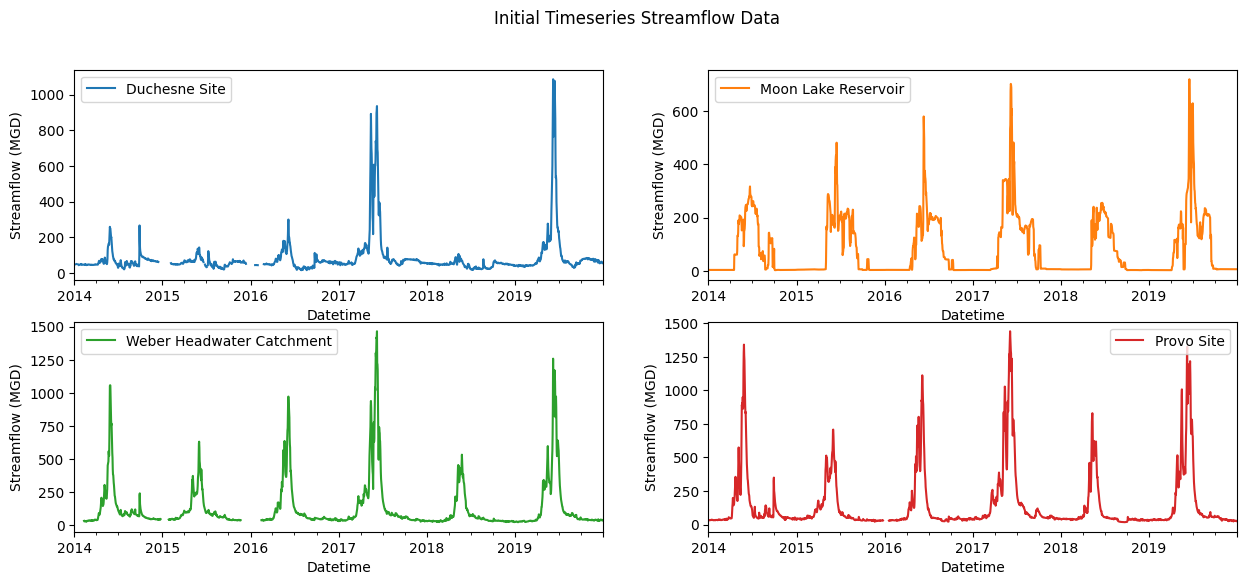

In [298]:
#Exploratory Data Analysis
streamflow.plot(title="Initial Timeseries Streamflow Data",
                figsize = (15,6),
                subplots=True,
                layout=(2,2),
                sharex=False,
                ylabel="Streamflow (MGD)")

# Task 3: Temporal Resampling & Statistical Aggregation

In [299]:
#raw daily
daily = streamflow
#weekly mean
weekly = streamflow.resample('W').mean()
#monthly total
monthly = streamflow.resample('ME').sum()

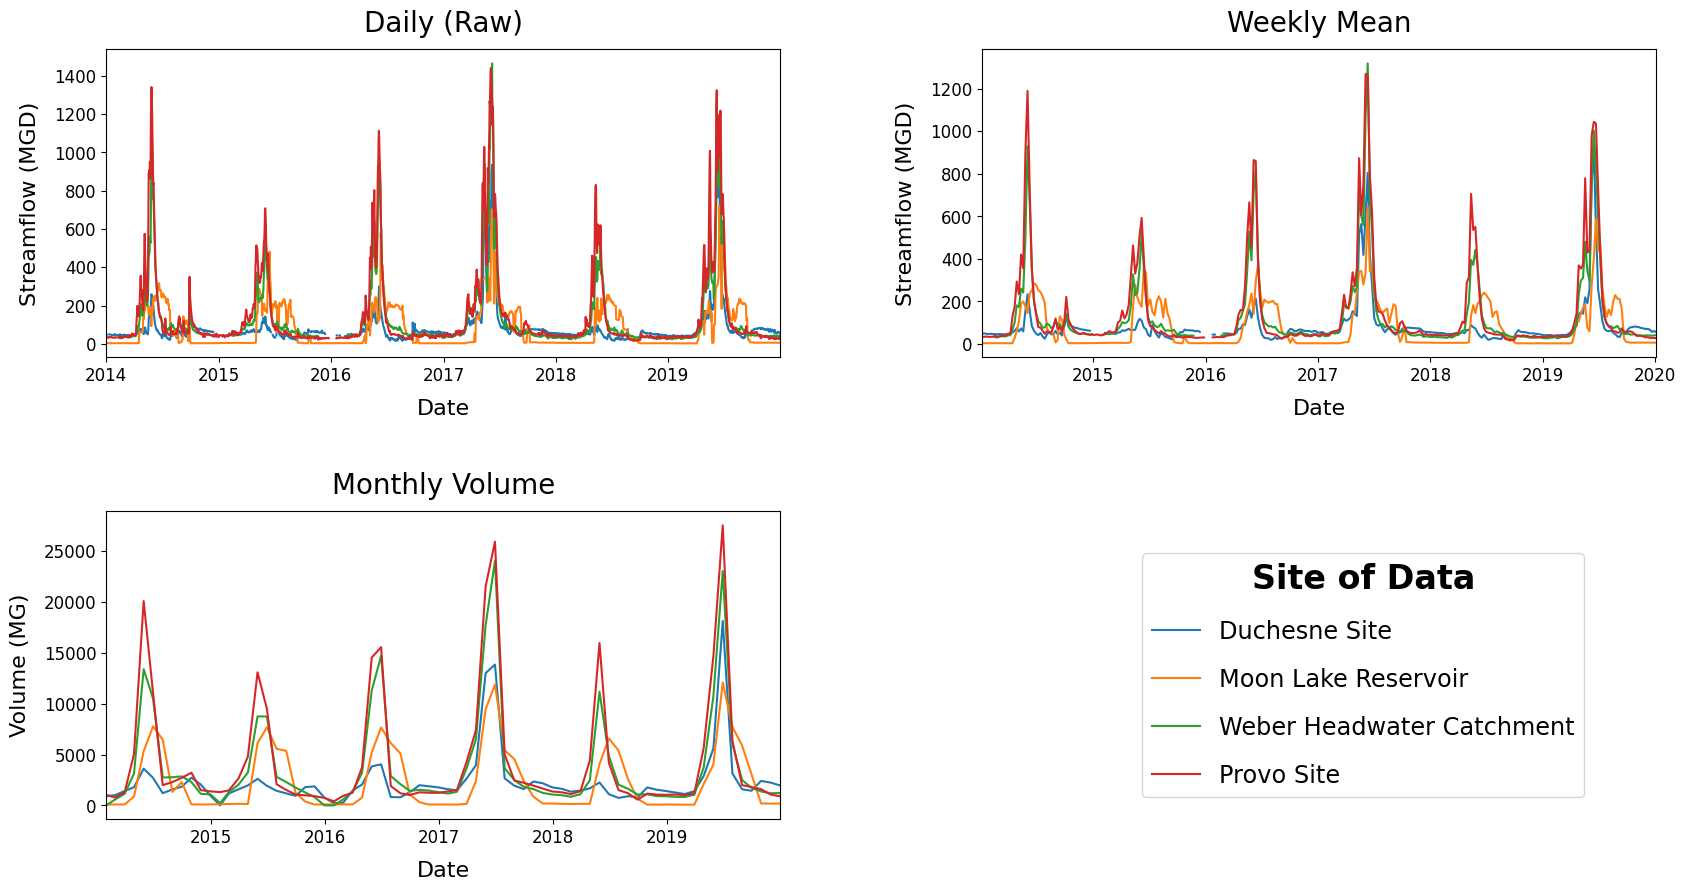

In [300]:
#Visualization
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20,10))

plotA = ax[0,0]
plotB = ax[0,1]
plotC = ax[1,0]
fig.delaxes(ax[1,1])

#daily plot
plotA.plot(daily)
plotA.set_title("Daily (Raw)",fontsize = 20,y=1.03)
plotA.set_xlabel("Date",fontsize = 16,labelpad=10)
plotA.set_ylabel("Streamflow (MGD)", fontsize = 16,labelpad=10)
plotA.set_xlim(daily.index.min(),daily.index.max())
plotA.tick_params(axis='both', labelsize=12)


#weekly plot
plotB.plot(weekly)
plotB.set_title("Weekly Mean",fontsize = 20,y=1.03)
plotB.set_xlabel("Date",fontsize = 16,labelpad=10)
plotB.set_ylabel("Streamflow (MGD)", fontsize = 16,labelpad=10)
plotB.set_xlim(weekly.index.min(),weekly.index.max())
plotB.tick_params(axis='both', labelsize=12)

#monthly plot
plotC.plot(monthly)
plotC.set_title("Monthly Volume",fontsize = 20,y=1.03)
plotC.set_xlabel("Date",fontsize = 16,labelpad=10)
plotC.set_ylabel("Volume (MG)", fontsize = 16,labelpad=10)
plotC.set_xlim(monthly.index.min(),monthly.index.max())
plotC.tick_params(axis='both', labelsize=12)

#Panel D -> legend
plt.subplots_adjust(hspace=0.5, wspace=0.3)
fig.legend(daily.columns.values, 
           loc='lower right',
           bbox_to_anchor=(0.87, 0.12),
           fontsize = 'xx-large',
           title = "Site of Data",
           labelspacing = 1,
           title_fontproperties = {'weight':'bold','size':24}
           )
plt.show()

# Task 4: Comparitive Analysis

In [301]:
#locations are Moon Lake Reservoir (gauge is below it) and Weber Headwater Catchment(see source/writeup for proof)
#wet year = 2019, dry year = 2015 (note that moon lake is slightly drier in 2018, but headwater is significantly wetter, making 2015 a better choice)

#Restrict locations for all plot types
daily = daily.drop(columns=["Duchesne Site","Provo Site"])
daily = daily.reset_index(drop=False)
weekly = weekly.drop(columns=["Duchesne Site","Provo Site"])
weekly = weekly.reset_index(drop=False)
monthly = monthly.drop(columns=["Duchesne Site","Provo Site"])
monthly = monthly.reset_index(drop=False)

In [302]:
#New cell block because the .drop() requires the "runall" button (too slow)
#Restrict time for plot types (water year is wet: Oct 2018- sep 2019, dry:Oct 2014- sep 2015)
wet_daily = daily.loc[daily.index[daily["Datetime"] == pd.Timestamp('2014-10-01')].min():daily.index[daily["Datetime"] == pd.Timestamp('2015-09-30')].min()].copy()
wet_daily["Datetime"] = pd.to_datetime(wet_daily["Datetime"])
wet_weekly = wet_daily.resample('W',on='Datetime').mean()

dry_daily = daily.loc[daily.index[daily["Datetime"] == pd.Timestamp('2018-10-01')].min():daily.index[daily["Datetime"] == pd.Timestamp('2019-09-30')].min()].copy()
dry_daily["Datetime"] = pd.to_datetime(dry_daily["Datetime"])
dry_weekly = dry_daily.resample('W',on='Datetime').mean()

#basic info of flow for each
moon_wet_daily = wet_daily["Moon Lake Reservoir"].describe()
moon_dry_daily = dry_daily["Moon Lake Reservoir"].describe()
weber_wet_daily = wet_daily['Weber Headwater Catchment'].describe()
weber_dry_daily = dry_daily['Weber Headwater Catchment'].describe()

#max/min daily
mwd_max = moon_wet_daily["max"]
mwd_min = moon_wet_daily["min"]
mdd_max = moon_dry_daily["max"]
mdd_min = moon_dry_daily["min"]

wwd_max = weber_wet_daily["max"]
wwd_min = weber_wet_daily["min"]
wdd_max = weber_dry_daily["max"]
wdd_min = weber_dry_daily["min"]

print("Range of Daily Flow Rates",'\n')
print(f"Maximum for the Wet Year: Moon Reservoir = {mwd_max:.3f} MGD, Weber Headwater Catchment = {wwd_max:.3f}",
      f"Minimum for the Wet Year: Moon Reservoir = {mwd_min:.3f}, Weber Headwater Catchment = {wwd_min:.3f}","",
      f"Maximum for the Dry Year: Moon Reservoir = {mdd_max:.3f}, Weber Headwater Catchment = {wdd_max:.3f}",
      f"Minimum for the Dry Year: Moon Reservoir = {mdd_min:.3f}, Weber Headwater Catchment = {wdd_min:.3f}", sep='\n')


#get aggregate for the wet year using daily values
agg_wet_daily = wet_daily.copy()
agg_wet_daily["Moon Lake Reservoir"] = agg_wet_daily["Moon Lake Reservoir"].cumsum()
agg_wet_daily["Weber Headwater Catchment"] = agg_wet_daily["Weber Headwater Catchment"].cumsum()

#get aggregate for the wet year using weekly average values
agg_wet_weekly = wet_weekly.copy()
agg_wet_weekly["Moon Lake Reservoir"] = agg_wet_weekly["Moon Lake Reservoir"].cumsum()
agg_wet_weekly["Weber Headwater Catchment"] = agg_wet_weekly["Weber Headwater Catchment"].cumsum()

#get aggregate for the dry year using daily values
agg_dry_daily = dry_daily.copy()
agg_dry_daily["Moon Lake Reservoir"] = agg_dry_daily["Moon Lake Reservoir"].cumsum()
agg_dry_daily["Weber Headwater Catchment"] = agg_dry_daily["Weber Headwater Catchment"].cumsum()

#get aggregate for the dry year using weekly average values
agg_dry_weekly = dry_weekly.copy()
agg_dry_weekly["Moon Lake Reservoir"] = agg_dry_weekly["Moon Lake Reservoir"].cumsum()
agg_dry_weekly["Weber Headwater Catchment"] = agg_dry_weekly["Weber Headwater Catchment"].cumsum()


Range of Daily Flow Rates 

Maximum for the Wet Year: Moon Reservoir = 481.606 MGD, Weber Headwater Catchment = 631.418
Minimum for the Wet Year: Moon Reservoir = 2.140, Weber Headwater Catchment = 40.898

Maximum for the Dry Year: Moon Reservoir = 720.155, Weber Headwater Catchment = 1258.623
Minimum for the Dry Year: Moon Reservoir = 2.112, Weber Headwater Catchment = 23.418


In [303]:
#fix data for plots
wet_daily["Datetime"] = pd.to_datetime(wet_daily["Datetime"])
wet_daily.set_index("Datetime", inplace=True)

dry_daily["Datetime"] = pd.to_datetime(dry_daily["Datetime"])
dry_daily.set_index("Datetime", inplace=True)

agg_wet_daily["Datetime"] = pd.to_datetime(agg_wet_daily["Datetime"])
agg_wet_daily.set_index("Datetime", inplace=True)

agg_dry_daily["Datetime"] = pd.to_datetime(agg_dry_daily["Datetime"])
agg_dry_daily.set_index("Datetime", inplace=True)

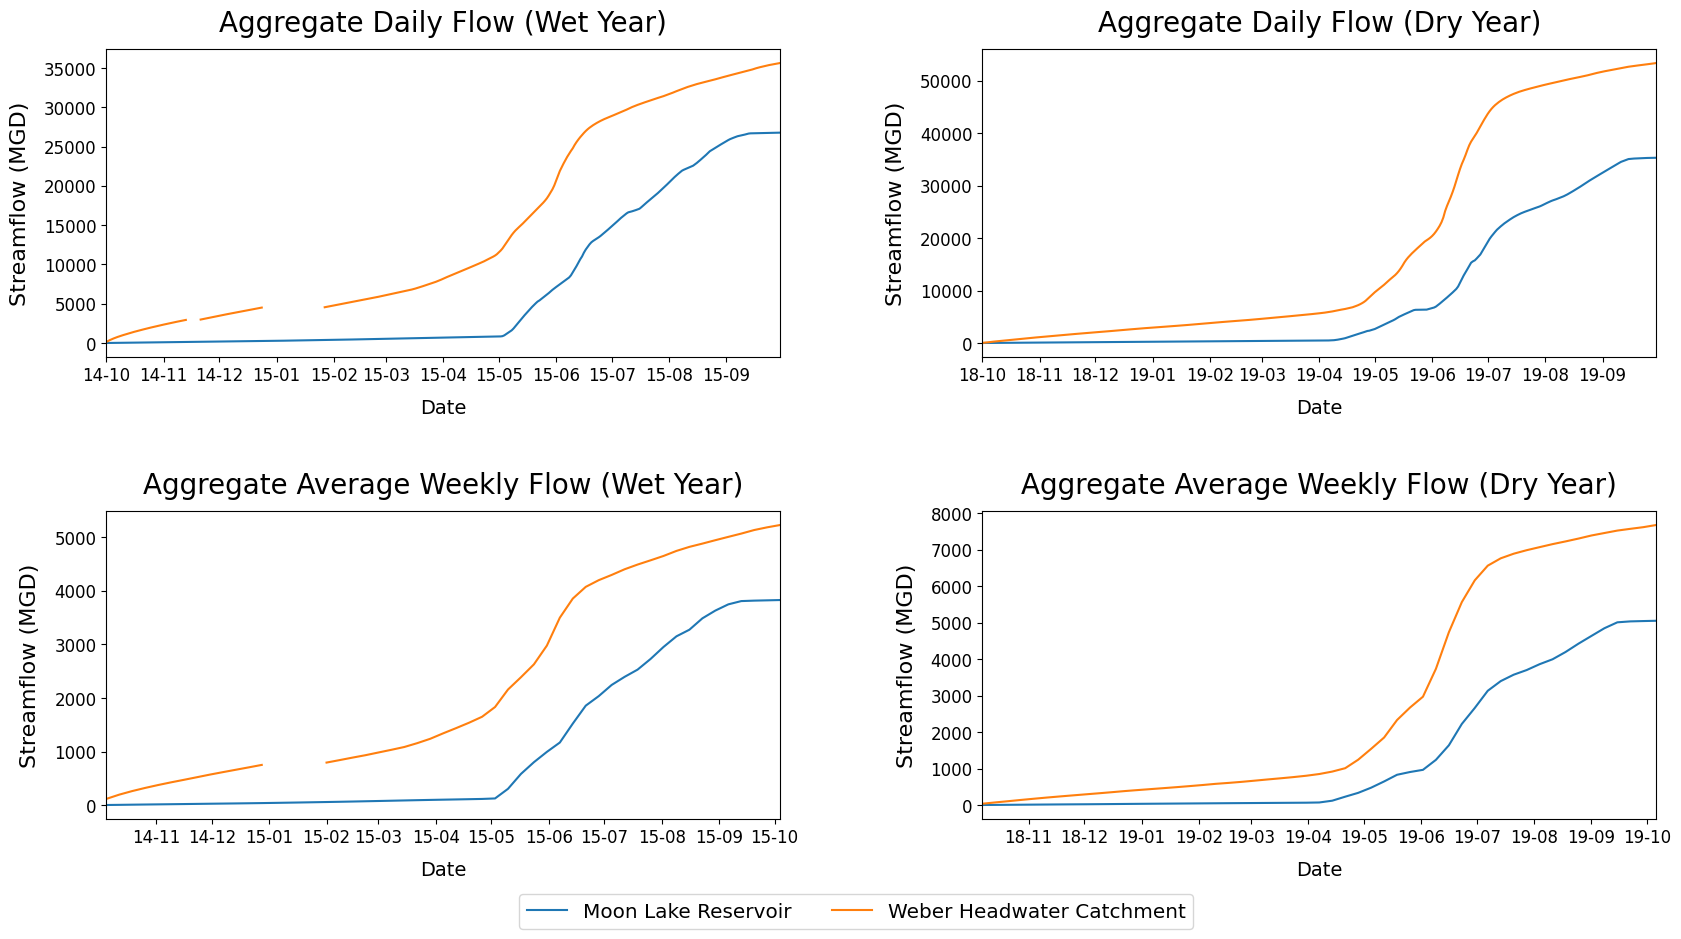

In [304]:
#plot for aggregate

myFmt = mdates.DateFormatter("%y-%m") 

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20,10))

plot1 = ax[0,0]
plot2 = ax[0,1]
plot3 = ax[1,0]
plot4 = ax[1,1]

plot1.plot(agg_wet_daily)
plot1.set_title("Aggregate Daily Flow (Wet Year)",fontsize = 20,y=1.03)
plot1.set_xlabel("Date",fontsize = 14,labelpad=10)
plot1.set_ylabel("Streamflow (MGD)", fontsize = 16,labelpad=10)
plot1.set_xlim(agg_wet_daily.index.min(),agg_wet_daily.index.max())
plot1.tick_params(axis='both', labelsize=12)
plot1.xaxis.set_major_formatter(myFmt)

plot2.plot(agg_dry_daily)
plot2.set_title("Aggregate Daily Flow (Dry Year)",fontsize = 20,y=1.03)
plot2.set_xlabel("Date",fontsize = 14,labelpad=10)
plot2.set_ylabel("Streamflow (MGD)", fontsize = 16,labelpad=10)
plot2.set_xlim(agg_dry_daily.index.min(),agg_dry_daily.index.max())
plot2.tick_params(axis='both', labelsize=12)
plot2.xaxis.set_major_formatter(myFmt)

plot3.plot(agg_wet_weekly)
plot3.set_title("Aggregate Average Weekly Flow (Wet Year)",fontsize = 20,y=1.03)
plot3.set_xlabel("Date",fontsize = 14,labelpad=10)
plot3.set_ylabel("Streamflow (MGD)", fontsize = 16,labelpad=10)
plot3.set_xlim(agg_wet_weekly.index.min(),agg_wet_weekly.index.max())
plot3.tick_params(axis='both', labelsize=12)
plot3.xaxis.set_major_formatter(myFmt)

plot4.plot(agg_dry_weekly)
plot4.set_title("Aggregate Average Weekly Flow (Dry Year)",fontsize = 20,y=1.03)
plot4.set_xlabel("Date",fontsize = 14,labelpad=10)
plot4.set_ylabel("Streamflow (MGD)", fontsize = 16,labelpad=10)
plot4.set_xlim(agg_dry_weekly.index.min(),agg_dry_weekly.index.max())
plot4.tick_params(axis='both', labelsize=12)
plot4.xaxis.set_major_formatter(myFmt)

plt.subplots_adjust(hspace=0.5, wspace=0.3)
fig.legend(agg_wet_daily.columns.values, 
           loc='lower center',
           fontsize = 'x-large',
           ncols=2,
           labelspacing = 1,
           bbox_to_anchor=(0.5, -0.01)
           )
plt.show()


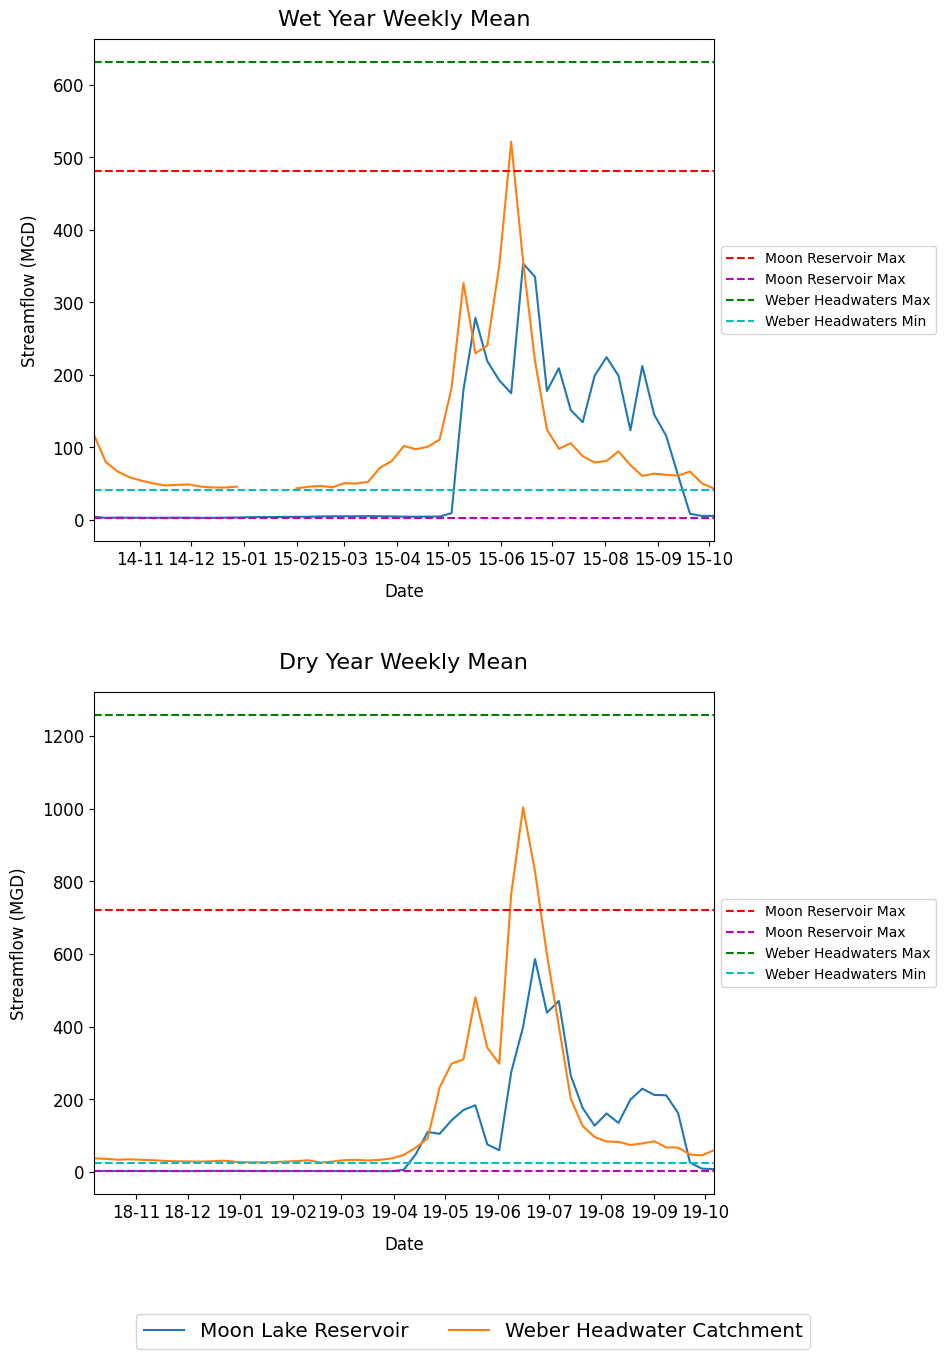

In [305]:
#Plots for daily max/min on weekly averages

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8,15))

plot_wet = ax[0]
plot_dry = ax[1]

wet_maxmin_list = [(mwd_max,'r',"Moon Reservoir Max"),
                    (mwd_min,'m',"Moon Reservoir Max"),
                    (wwd_max,'g',"Weber Headwaters Max"),
                     (wwd_min,'c',"Weber Headwaters Min")]

dry_maxmin_list = [(mdd_max,'r',"Moon Reservoir Max"),
                    (mdd_min,'m',"Moon Reservoir Max"),
                    (wdd_max,'g',"Weber Headwaters Max"),
                     (wdd_min,'c',"Weber Headwaters Min")]


plot_wet.plot(wet_weekly)
plot_wet.set_title("Wet Year Weekly Mean",fontsize = 16,y=1.01)
plot_wet.set_xlabel("Date",fontsize = 12,labelpad=10)
plot_wet.set_ylabel("Streamflow (MGD)", fontsize = 12,labelpad=10)
plot_wet.set_xlim(wet_weekly.index.min(),wet_weekly.index.max())
plot_wet.tick_params(axis='both', labelsize=12)
plot_wet.xaxis.set_major_formatter(myFmt)

[plot_wet.axhline(y=i[0],linestyle='--',color=i[1], label=i[2]) for i in wet_maxmin_list]
plot_wet.legend(loc='center left',bbox_to_anchor=(1, 0.5))

plot_dry.plot(dry_weekly)
plot_dry.set_title("Dry Year Weekly Mean",fontsize = 16,y=1.03)
plot_dry.set_xlabel("Date",fontsize = 12,labelpad=10)
plot_dry.set_ylabel("Streamflow (MGD)", fontsize = 12,labelpad=10)
plot_dry.set_xlim(dry_weekly.index.min(),dry_weekly.index.max())
plot_dry.tick_params(axis='both', labelsize=12)
plot_dry.xaxis.set_major_formatter(myFmt)

[plot_dry.axhline(y=i[0],linestyle='--',color=i[1], label=i[2]) for i in dry_maxmin_list]
plot_dry.legend(loc='center left',bbox_to_anchor=(1, 0.5))

plt.subplots_adjust(hspace=0.3, wspace=0.3)
fig.legend(wet_weekly.columns.values, 
           loc='lower center',
           fontsize = 'x-large',
           ncols=2,
           labelspacing = 1,
           )
plt.show()